#### 1. Relevant Imports

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm


#### 2. Downloading Data, Setting up Data Loaders

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

root = "./data"

train_dataset = torchvision.datasets.MNIST(
    root=root,
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root=root,
    train=False,
    transform=transform,
    download=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 47.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.16MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.73MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


In [3]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

#### 3. VAE Architecture Class

In [ ]:

class VAE(nn.Module):
    def __init__(self, input_dim=28*28, latent_dim=20, hidden_dim=500):
        super().__init__()
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        
        # Encoder
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.layer2 = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU()
        )

        self.decoder_out = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.layer1(x)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        
        z = mu + std * eps

        return z

    def decode(self, z):
        x = self.layer2(z)
        x = self.decoder_out(x)
        x = torch.sigmoid(x)

        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)

        x_hat = x_hat.view(-1, 1, 28, 28)

        return x_hat, mu, logvar

#### 4. Model Training

In [5]:
model_1 = VAE()
optimizer = optim.Adam(model_1.parameters(), lr=1e-3)
epochs = 30

def vae_loss(x, x_hat, mu, logvar):
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction="sum")

    kl_loss = 0.5 * torch.sum(torch.exp(logvar) + mu.pow(2) - logvar - 1)

    return recon_loss + kl_loss


# Training loop
def train(model, train_loader, loss_fn, optimizer, epochs):
    train_losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0

        for x, _ in train_loader:
            optimizer.zero_grad()

            x_hat, mu, logvar = model(x)
            loss = loss_fn(x, x_hat, mu, logvar)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
        print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.2f}")

    return train_losses

# Test loop
def test(model, test_loader, loss_fn):
    model.eval()
    test_loss = 0

    with torch.no_grad():
        for x, _ in test_loader:
            x_hat, mu, logvar = model(x)
            loss = loss_fn(x, x_hat, mu, logvar)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader.dataset)
    print(f"Test Loss: {avg_test_loss:.2f}")


# Plot helper function

def plot(train_losses):
  plt.plot(train_losses, color="tab:blue")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.title("Training Loss")
  plt.show()

In [6]:
train_losses = train(model_1, train_loader, vae_loss, optimizer, epochs)


Epoch 1 | Train Loss: 184.28
Epoch 2 | Train Loss: 130.12
Epoch 3 | Train Loss: 119.00
Epoch 4 | Train Loss: 114.62
Epoch 5 | Train Loss: 112.20
Epoch 6 | Train Loss: 110.60
Epoch 7 | Train Loss: 109.46
Epoch 8 | Train Loss: 108.60
Epoch 9 | Train Loss: 107.81
Epoch 10 | Train Loss: 107.25
Epoch 11 | Train Loss: 106.84
Epoch 12 | Train Loss: 106.44
Epoch 13 | Train Loss: 106.07
Epoch 14 | Train Loss: 105.73
Epoch 15 | Train Loss: 105.45
Epoch 16 | Train Loss: 105.24
Epoch 17 | Train Loss: 105.02
Epoch 18 | Train Loss: 104.83
Epoch 19 | Train Loss: 104.58
Epoch 20 | Train Loss: 104.44
Epoch 21 | Train Loss: 104.24
Epoch 22 | Train Loss: 104.10
Epoch 23 | Train Loss: 103.97
Epoch 24 | Train Loss: 103.82
Epoch 25 | Train Loss: 103.70
Epoch 26 | Train Loss: 103.58
Epoch 27 | Train Loss: 103.47
Epoch 28 | Train Loss: 103.33
Epoch 29 | Train Loss: 103.26
Epoch 30 | Train Loss: 103.14


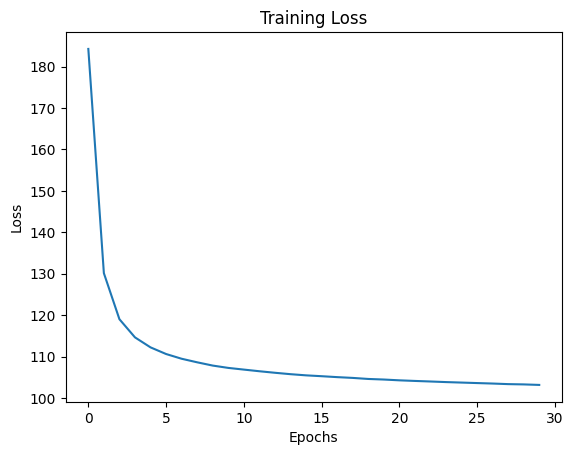

In [7]:
plot(train_losses)

In [8]:
test(model_1, test_loader, vae_loss)

Test Loss: 103.22


#### 5. Analyzing VAE Performance

In [ ]:
# Training model with latent space dimension as 2

model_2 = VAE(latent_dim = 2)
optimizer = optim.Adam(model_2.parameters(), lr=1e-3)

In [11]:
train_losses_2 = train(model_2, train_loader, vae_loss, optimizer, epochs)

Epoch 1 | Train Loss: 201.02
Epoch 2 | Train Loss: 170.94
Epoch 3 | Train Loss: 165.32
Epoch 4 | Train Loss: 162.50
Epoch 5 | Train Loss: 160.51
Epoch 6 | Train Loss: 159.12
Epoch 7 | Train Loss: 157.99
Epoch 8 | Train Loss: 157.12
Epoch 9 | Train Loss: 156.32
Epoch 10 | Train Loss: 155.68
Epoch 11 | Train Loss: 155.04
Epoch 12 | Train Loss: 154.47
Epoch 13 | Train Loss: 154.02
Epoch 14 | Train Loss: 153.55
Epoch 15 | Train Loss: 153.06
Epoch 16 | Train Loss: 152.65
Epoch 17 | Train Loss: 152.33
Epoch 18 | Train Loss: 151.91
Epoch 19 | Train Loss: 151.59
Epoch 20 | Train Loss: 151.30
Epoch 21 | Train Loss: 151.01
Epoch 22 | Train Loss: 150.68
Epoch 23 | Train Loss: 150.45
Epoch 24 | Train Loss: 150.11
Epoch 25 | Train Loss: 149.87
Epoch 26 | Train Loss: 149.62
Epoch 27 | Train Loss: 149.43
Epoch 28 | Train Loss: 149.23
Epoch 29 | Train Loss: 149.03
Epoch 30 | Train Loss: 148.81


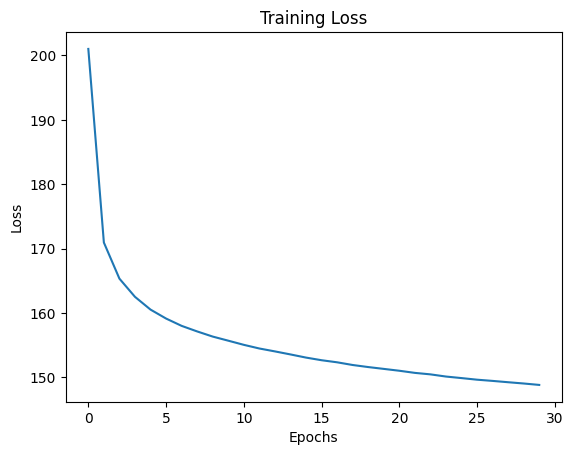

In [12]:
plot(train_losses_2)

In [13]:
test(model_2, test_loader, vae_loss)

Test Loss: 150.60


#### 5. (i) Organization of Latent Spaces

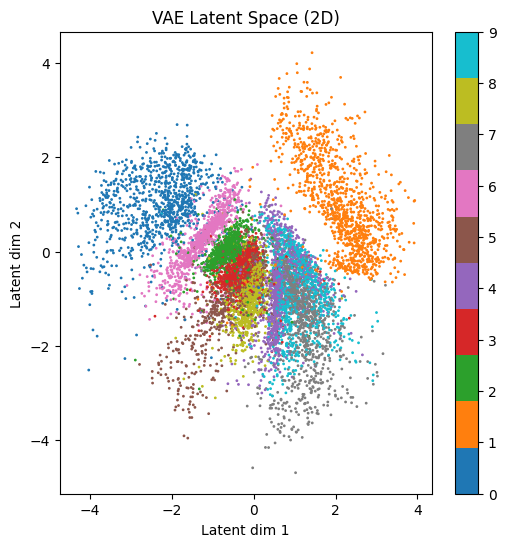

In [16]:
mus = []
labels = []

model_2.eval()

with torch.no_grad():
    for x, y in test_loader:
        mu, logvar = model_2.encode(x)

        mus.append(mu.cpu().numpy())
        labels.append(y.numpy())

mus = np.vstack(mus)
labels = np.concatenate(labels)

plt.figure(figsize=(6, 6))
plt.scatter(mus[:, 0], mus[:, 1], c=labels, cmap="tab10", s=1)
plt.colorbar()
plt.xlabel("Latent dim 1")
plt.ylabel("Latent dim 2")
plt.title("VAE Latent Space (2D)")
plt.show()

#### 5. (ii) Reconstruction Quality

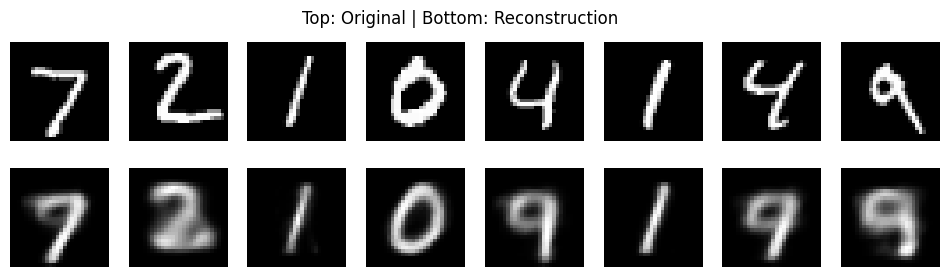

In [17]:
model_2.eval()

dataiter = iter(test_loader)
x, _ = next(dataiter)

with torch.no_grad():
    x_hat, mu, logvar = model_2(x)

n = 8

plt.figure(figsize=(12, 3))

for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(x[i].squeeze(), cmap="gray")
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_hat[i].squeeze().cpu(), cmap="gray")
    plt.axis("off")

plt.suptitle("Top: Original | Bottom: Reconstruction")
plt.show()

#### 5. (iii) Sampling from an Isotropic Gaussian Distribution and Generating Samples via Decoder

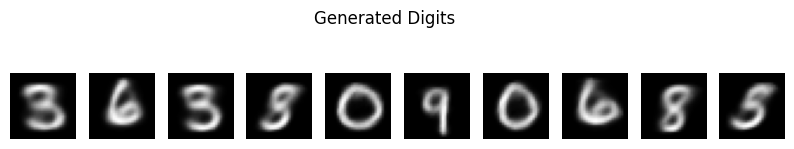

In [18]:
model_2.eval()

num_samples = 10

with torch.no_grad():
    z = torch.randn(num_samples, model_2.latent_dim)
    samples = model_2.decode(z)

samples = samples.view(-1, 1, 28, 28).cpu()

plt.figure(figsize=(10, 2))

for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(samples[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Generated Digits")
plt.show()